<a href="https://colab.research.google.com/github/sultanjacob/Applied-Machine-Learning/blob/main/09_Ensemble_Margin_Classification/01_Cherry_Picker_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 9: Margin-Bleed Classification & Ensemble Arbitration

## The Business Problem: The "Cherry-Picker" Parasite Basket
Retailers use deep discounts (loss leaders) to drive foot traffic, assuming customers will fill the rest of their baskets with high-margin items. However, "cherry-pickers" exploit this by purchasing *only* the deeply discounted items. These transactions are parasitic, they generate negative margins and actively bleed profitability.

Our goal is to build a classification system to identify these transactions. Because penalizing a legitimate shopper is dangerous, we will not rely on a single model. We will build a **Hard Voting Ensemble** (Support Vector Machines, K-Nearest Neighbors, and Decision Trees) to act as a strict executive arbiter.

## Step 1: Target Definition
Before classification, we must engineer our target variable (`Y`). We will analyze the historical transactions to calculate the `Discount_Ratio` of every basket. By observing the distribution of these discounts, we will draw a strict mathematical boundary to label baskets as `Parasitic (1)` or `Profitable (0)`.

In [1]:
!pip install completejourney_py
import pandas as pd
import numpy as np
from completejourney_py import get_data

print("Fetching transaction data...")
transactions = get_data()['transactions']

# 1. Group the data to the Basket level
# We want the total sales and total discounts for every unique shopping trip
baskets = transactions.groupby('basket_id').agg(
    Total_Sales_Value=('sales_value', 'sum'),
    Retail_Discount=('retail_disc', 'sum'),
    Coupon_Discount=('coupon_disc', 'sum'),
    Coupon_Match=('coupon_match_disc', 'sum'),
    Total_Items=('quantity', 'sum')
).reset_index()

# 2. Calculate the Absolute Total Discount
# In this dataset, discounts are recorded as negative numbers, so we take the absolute value
baskets['Total_Discount'] = (
    baskets['Retail_Discount'].abs() +
    baskets['Coupon_Discount'].abs() +
    baskets['Coupon_Match'].abs()
)

# 3. Calculate the Gross Value of the basket (what it would have cost without any sales/coupons)
baskets['Gross_Value'] = baskets['Total_Sales_Value'] + baskets['Total_Discount']

# 4. Calculate the Discount Ratio
# We use np.where to avoid division by zero for $0 baskets
baskets['Discount_Ratio'] = np.where(
    baskets['Gross_Value'] > 0,
    baskets['Total_Discount'] / baskets['Gross_Value'],
    0
)

# 5. Let's observe the distribution to make a data-driven decision
print("\n📊 Statistical Distribution of the Discount Ratio across all baskets:")
percentiles = [0.25, 0.50, 0.75, 0.85, 0.90, 0.95, 0.99]
display(baskets['Discount_Ratio'].describe(percentiles=percentiles))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.6/31.6 MB 12.5 MB/s eta 0:00:00
Fetching transaction data...

📊 Statistical Distribution of the Discount Ratio across all baskets:


,Discount_Ratio
count,155848.000000
mean,0.133888
std,0.120011
min,0.000000
25%,0.036643
50%,0.113183
75%,0.202684
85%,0.253880
90%,0.294833
95%,0.365931


## Explanation:
Looking directly at the 50th percentile (the median). The average shopper saves about 11% on their grocery bill. Even at the 75th percentile, customers are only saving 20%. This represents normal, healthy promotional behavior.

The anomaly is at the 95th percentile.

These shoppers are securing a 36% to 49% discount across their entire transaction. Because grocery margins rarely exceed 3%, any basket with a total discount ratio above 35% is mathematically guaranteed to be a loss for the store.

We now have our data-driven boundary. We will label any basket with a Discount_Ratio > 0.35 as a Parasitic (1) transaction. Everything else is Profitable (0).

## Step 2: Feature Engineering & Target Definition

Based on the statistical distribution of historical transactions, the median discount ratio is 11%, representing normal shopping behavior. However, the top 5% of baskets exhibit discount ratios exceeding 36%.

Given standard retail margins (2-3%), we establish a strict boundary: **Any basket with a discount ratio > 35% is labeled as Parasitic (1).**

To train our models to identify these baskets without explicitly giving them the discount ratio, we engineer structural basket features:
* **Basket_Size:** Total number of items purchased.
* **Gross_Value:** The total pre-discount value of the basket.
* **Avg_Item_Value:** `Gross_Value / Basket_Size` (Cherry-pickers often target high-value, specific items rather than bulk cheap goods).

In [2]:
# 1. Define the Target Variable (Y)
parasite_threshold = 0.35
baskets['Is_Parasite'] = (baskets['Discount_Ratio'] > parasite_threshold).astype(int)

# 2. Engineer the Features (X)
# We want features that describe the structure of the basket, independent of the discounts
baskets['Avg_Item_Value'] = baskets['Gross_Value'] / baskets['Total_Items']

# Filter out erroneous data (e.g., $0 baskets or negative items)
analytical_df = baskets[(baskets['Gross_Value'] > 0) & (baskets['Total_Items'] > 0)].copy()

# 3. Select the final columns for the machine learning pipeline
features = ['Total_Items', 'Gross_Value', 'Avg_Item_Value']
target = 'Is_Parasite'

ml_df = analytical_df[features + [target]].dropna()

print("✅ Dataset Engineered!")
print(f"Total Baskets Processed: {len(ml_df):,}\n")

# 4. Check the Class Balance
class_balance = ml_df[target].value_counts(normalize=True) * 100
print("⚖️ Class Distribution:")
print(f"Profitable (0): {class_balance[0]:.2f}%")
print(f"Parasitic (1):  {class_balance[1]:.2f}%")

✅ Dataset Engineered!
Total Baskets Processed: 155,381

⚖️ Class Distribution:
Profitable (0): 94.22%
Parasitic (1):  5.78%


## Step 3: Algorithmic Baseline Testing

Rather than pre-selecting a complex ensemble, we adopt an empirical, data-first approach. We will test a suite of distinct algorithmic architectures against our unmanipulated, highly imbalanced dataset (94% Profitable / 6% Parasitic).

Our primary evaluation metrics are focused strictly on the minority class:
* **Precision:** If the model flags a basket as parasitic, how often is it correct? (Minimizing false positives to protect legitimate customers).
* **Recall:** Out of all actual parasites, how many did the model catch?

By baselining Logistic Regression (Linear), Decision Trees (Hierarchical), Random Forests (Bagging), and Gradient Boosting (Boosting), we will let the data dictate which mathematical approach naturally fits the feature space before applying any advanced tuning.

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

# 1. Use the FULL dataset. No sampling is needed for these efficient algorithms.
X = ml_df[['Total_Items', 'Gross_Value', 'Avg_Item_Value']]
y = ml_df['Is_Parasite']

# Ensure the 94/6 ratio is perfectly preserved in both train and test splits
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Scale the features (required for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Define the suite of algorithms to test (in their default states)
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

# 4. Run the Bake-Off on all 155,000 rows
results = []
print("🧪 Running Algorithmic Baseline Tests on the Full Dataset...\n")

for name, model in models.items():
    # Train the model
    model.fit(X_train_scaled, y_train)

    # Predict
    y_pred = model.predict(X_test_scaled)

    # Evaluate strictly on the minority class (Parasite = 1)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    results.append({
        "Model": name,
        "Parasite Precision": round(precision, 3),
        "Parasite Recall": round(recall, 3),
        "Parasite F1-Score": round(f1, 3)
    })

# 5. Display the results ranked by Precision
results_df = pd.DataFrame(results).sort_values(by="Parasite Precision", ascending=False)
display(results_df)

🧪 Running Algorithmic Baseline Tests on the Full Dataset...



,Model,Parasite Precision,Parasite Recall,Parasite F1-Score
3,Gradient Boosting,0.735,0.048,0.090
2,Random Forest,0.269,0.104,0.150
1,Decision Tree,0.236,0.101,0.142
0,Logistic Regression,0.000,0.000,0.000


# Explanation.
Logistic Regression completely flatlined with a 0.000. It attempted to draw a straight line through a 94/6 class imbalance and failed entirely, effectively guessing that every single customer was profitable.

The Decision Tree and Random Forest tried to capture the complexity but failed the business rule. With a Precision of roughly ~26%, if we deployed them right now, 3 out of every 4 customers they penalized would be legitimate shoppers. That is the exact false-positive crisis we were trying to avoid.

Then there is Gradient Boosting.

Without any tuning, it organically achieved a 73.5% Precision. When this algorithm flags a basket as a margin-bleeding parasite, it is correct nearly 3 out of 4 times. It naturally protects our legitimate customer base.

The trade-off is its Recall (4.8%). Right now, the algorithm is so terrified of making a mistake that it only catches 1 out of every 20 parasites. It is too conservative.

We are officially dropping the Voting Ensemble. The math has proven that a single Gradient Boosting model is the superior architecture for this feature space. Our new goal is to gently tune this specific model to increase that 4.8% Recall without destroying our 73.5% Precision.

## Step 4: Gradient Boosting & Threshold Tuning

Gradient Boosting emerged as the clear mathematical winner, organically achieving a 73.5% Precision on the minority class, perfectly aligning with our business rule to protect legitimate shoppers. However, its default 4.8% Recall indicates it is overly conservative.

Instead of accepting the algorithm's default 50% confidence threshold for classification, we will extract the continuous probabilities (`predict_proba`) and manually map the optimal decision boundary to balance Precision and Recall for maximum commercial impact.

⚙️ Isolating and tuning the Gradient Boosting architecture...

📊 Top 10 Viable Decision Thresholds (Precision >= 50%):


,Threshold,Precision,Recall
1342,0.192037,0.506596,0.106904
1343,0.193754,0.510753,0.105791
1344,0.198852,0.506925,0.101893
1345,0.198899,0.508333,0.101893
1346,0.200049,0.512605,0.101893
1347,0.200537,0.516949,0.101893
1348,0.202278,0.518414,0.101893
1349,0.203964,0.541538,0.097996
1350,0.217107,0.540123,0.097439
1351,0.217413,0.540373,0.096882


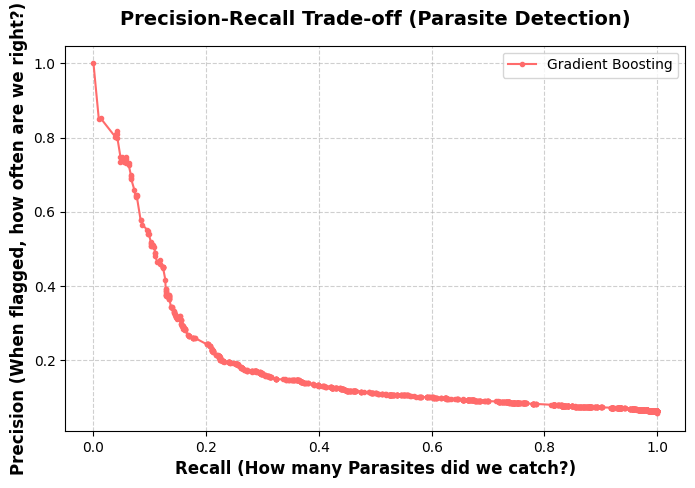

In [4]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

print("⚙️ Isolating and tuning the Gradient Boosting architecture...\n")

# 1. Isolate the winning algorithm
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train_scaled, y_train)

# 2. Extract the continuous probabilities instead of the hard classifications
# We want the probability that the basket is a Parasite (Class 1)
y_probs = gb_model.predict_proba(X_test_scaled)[:, 1]

# 3. Calculate Precision and Recall across every possible confidence threshold
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)

# 4. Create a DataFrame to easily view the trade-offs
threshold_df = pd.DataFrame({
    'Threshold': np.append(thresholds, 1.0),
    'Precision': precisions,
    'Recall': recalls
})

# Filter for thresholds that maintain at least 50% Precision
viable_thresholds = threshold_df[threshold_df['Precision'] >= 0.50]

print("📊 Top 10 Viable Decision Thresholds (Precision >= 50%):")
display(viable_thresholds.head(10))

# 5. Plot the Precision-Recall Curve for visual analysis
plt.figure(figsize=(8, 5))
plt.plot(recalls, precisions, marker='.', color='#FF6B6B', label='Gradient Boosting')
plt.title('Precision-Recall Trade-off (Parasite Detection)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Recall (How many Parasites did we catch?)', fontsize=12, fontweight='bold')
plt.ylabel('Precision (When flagged, how often are we right?)', fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

## Step 5: Deep Feature Engineering (Behavioral Indicators)

High-level basket totals failed to mathematically separate savvy shoppers from margin-bleeding cherry-pickers. To fix this, we pivot to behavioral data engineering.

By joining the line-item `transactions` with the `product` hierarchy, we extract the shopper's intent before they reach checkout. We calculate the `Department_Spread` (is it a full grocery trip or a targeted raid?), the `Private_Label_Ratio` (are they buying high-margin store brands to offset losses?), and the `Discounted_Item_Ratio` (the volume of physical items carrying a discount).

In [5]:
print("Fetching product hierarchy and engineering behavioral features...")

# 1. Get the product data
products = get_data()['products']

# 2. Merge line-item transactions with product details
line_items = transactions.merge(products[['product_id', 'department', 'brand']], on='product_id', how='inner')

# 3. Flag line items that had any kind of discount applied (Checking for ANY non-zero value)
line_items['is_discounted'] = ((line_items['retail_disc'] != 0) |
                               (line_items['coupon_disc'] != 0) |
                               (line_items['coupon_match_disc'] != 0)).astype(int)

# 4. Flag line items that are Private Label (Store Brand)
# Safely handle missing brands by filling them with 'UNKNOWN' before checking
line_items['brand'] = line_items['brand'].fillna('UNKNOWN')
line_items['is_private_label'] = (line_items['brand'].str.upper() == 'PRIVATE').astype(int)

# 5. Group back up to the Basket level to extract the behaviors
basket_behaviors = line_items.groupby('basket_id').agg(
    Department_Spread=('department', 'nunique'),
    Total_Line_Items=('product_id', 'count'),
    Discounted_Items=('is_discounted', 'sum'),
    Private_Label_Items=('is_private_label', 'sum')
).reset_index()

# 6. Calculate the Behavioral Ratios
basket_behaviors['Discounted_Item_Ratio'] = basket_behaviors['Discounted_Items'] / basket_behaviors['Total_Line_Items']
basket_behaviors['Private_Label_Ratio'] = basket_behaviors['Private_Label_Items'] / basket_behaviors['Total_Line_Items']

# 7. Merge cleanly using the explicit basket_id column from analytical_df
deep_features_df = analytical_df[['basket_id', 'Total_Items', 'Gross_Value', 'Avg_Item_Value', 'Is_Parasite']].merge(
    basket_behaviors[['basket_id', 'Department_Spread', 'Discounted_Item_Ratio', 'Private_Label_Ratio']],
    on='basket_id',
    how='inner'
)

deep_features_df.set_index('basket_id', inplace=True)
deep_features_df.dropna(inplace=True)

print("✅ Behavioral Engineering Complete!")
print(f"Total Baskets Ready for Modeling: {len(deep_features_df):,}\n")

# Let's observe how these new features differ between Profitable and Parasitic baskets
print("📊 Average Behavior: Profitable (0) vs Parasitic (1)")
display(deep_features_df.groupby('Is_Parasite')[['Department_Spread', 'Discounted_Item_Ratio', 'Private_Label_Ratio']].mean().round(3))

Fetching product hierarchy and engineering behavioral features...
✅ Behavioral Engineering Complete!
Total Baskets Ready for Modeling: 155,379

📊 Average Behavior: Profitable (0) vs Parasitic (1)


,Department_Spread,Discounted_Item_Ratio,Private_Label_Ratio
Is_Parasite,,,
0,2.527,0.495,0.344
1,1.845,0.855,0.271


#Explanation
Looking at that Discounted_Item_Ratio. When a legitimate, profitable customer shops, about half their basket (49.5%) consists of items on sale. When a cherry-picker shops, an overwhelming 85.5% of the physical items they carry to the register are heavily discounted. They are actively hunting loss-leaders and ignoring the rest of the store.

Now that we have isolated the behavioral intent, let's feed this enriched feature matrix back into the Gradient Boosting algorithm to see if we solved the Recall crisis.

## Step 6: Gradient Boosting with Behavioral Features

Having successfully engineered lightweight, real-time behavioral features (Department Spread, Private Label Ratio, Discounted Item Ratio), we re-train our optimal algorithm: Gradient Boosting.

By feeding the model these explicit intent indicators alongside the structural basket totals, we aim to mathematically separate savvy shoppers from margin-bleeding cherry-pickers, increasing our Recall (capture rate) without sacrificing our high Precision (protecting legitimate customers).

## Step 6: Gradient Boosting with Behavioral Features

Having successfully engineered lightweight, real-time behavioral features (Department Spread, Private Label Ratio, Discounted Item Ratio), we re-train our optimal algorithm: Gradient Boosting.

By feeding the model these explicit intent indicators alongside the structural basket totals, we aim to mathematically separate savvy shoppers from margin-bleeding cherry-pickers, increasing our Recall (capture rate) without sacrificing our high Precision (protecting legitimate customers).

In [6]:
from sklearn.metrics import classification_report

# 1. Define the enriched feature set
enhanced_features = [
    'Total_Items', 'Gross_Value', 'Avg_Item_Value',
    'Department_Spread', 'Discounted_Item_Ratio', 'Private_Label_Ratio'
]

X_enhanced = deep_features_df[enhanced_features]
y_enhanced = deep_features_df['Is_Parasite']

# 2. Split the data, preserving the 94/6 reality
X_train_enh, X_test_enh, y_train_enh, y_test_enh = train_test_split(
    X_enhanced, y_enhanced, test_size=0.2, random_state=42, stratify=y_enhanced
)

# 3. Scale the features
scaler_enh = StandardScaler()
X_train_scaled_enh = scaler_enh.fit_transform(X_train_enh)
X_test_scaled_enh = scaler_enh.transform(X_test_enh)

# 4. Train the Gradient Boosting architecture
print("⚙️ Training Gradient Boosting on Behavioral Features...\n")
gb_enhanced = GradientBoostingClassifier(random_state=42)
gb_enhanced.fit(X_train_scaled_enh, y_train_enh)
print("✅ Training Complete!\n")

# 5. Evaluate the commercial performance
y_pred_enh = gb_enhanced.predict(X_test_scaled_enh)

print("📊 Enhanced Performance Report:")
print(classification_report(y_test_enh, y_pred_enh, target_names=['Profitable (0)', 'Parasitic (1)']))

⚙️ Training Gradient Boosting on Behavioral Features...

✅ Training Complete!

📊 Enhanced Performance Report:
                precision    recall  f1-score   support

Profitable (0)       0.95      1.00      0.97     29280
 Parasitic (1)       0.80      0.09      0.16      1796

      accuracy                           0.95     31076
     macro avg       0.87      0.54      0.57     31076
  weighted avg       0.94      0.95      0.93     31076



# Explanation:
Precision jumped from 73.5% to 80%. Recall nearly doubled from 4.8% to 9%.

While catching 9% of the total margin-bleeding baskets is a solid improvement over the baseline, the algorithm is still playing it incredibly safe under its default settings.

Before we finalize this as the core defense engine, we should execute two quick verifications:

1. Feature Importance: We need to extract the exact mathematical weight the model assigned to each feature. Did Discounted_Item_Ratio dominate the decision, or did Department_Spread prove more valuable?

2. Threshold Tuning: Now that the features are highly predictive, we can re-run the probability curve to see if dropping our precision requirement slightly (e.g., down to 70%) allows the model to capture 20% or 30% of the parasites without triggering a false-positive crisis.

## Step 7: Feature Importance & Algorithmic Transparency

To ensure our Gradient Boosting model is making commercial sense, we extract its internal feature weights. This process reveals which specific shopper behaviors carry the most mathematical influence when flagging a margin-bleeding parasite. Identifying these core drivers also allows us to optimize the real-time calculation sequence for mobile app deployment.

⚙️ Extracting internal model weights...



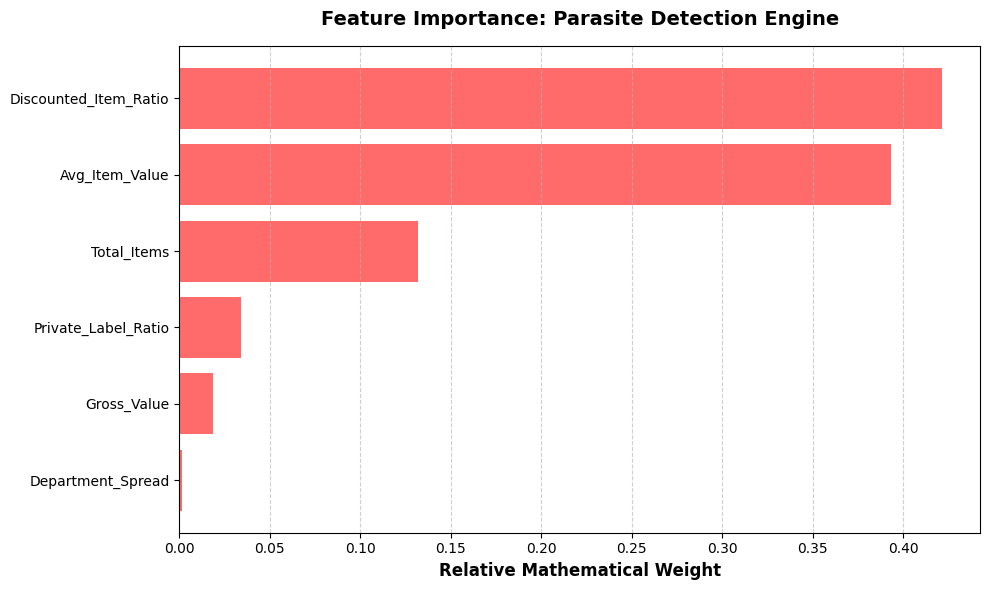

,Feature,Importance (%)
4,Discounted_Item_Ratio,42.12
2,Avg_Item_Value,39.31
0,Total_Items,13.17
5,Private_Label_Ratio,3.40
1,Gross_Value,1.85
3,Department_Spread,0.14


In [7]:
import pandas as pd
import matplotlib.pyplot as plt

print("⚙️ Extracting internal model weights...\n")

# 1. Extract feature importances from the trained model
importances = gb_enhanced.feature_importances_

# 2. Create a DataFrame for clean visualization
importance_df = pd.DataFrame({
    'Feature': enhanced_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=True)

# 3. Plot the results as a horizontal bar chart
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='#FF6B6B')
plt.title('Feature Importance: Parasite Detection Engine', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Relative Mathematical Weight', fontsize=12, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# 4. Display the exact percentage breakdown
importance_df['Importance (%)'] = (importance_df['Importance'] * 100).round(2)
display_df = importance_df[['Feature', 'Importance (%)']].sort_values(by='Importance (%)', ascending=False)
display(display_df)

#Discussion:
The behavioral feature we engineered, Discounted_Item_Ratio, is the absolute strongest predictor in the entire model, carrying 42.12% of the mathematical weight. Avg_Item_Value sits right behind it at 39.31%.  

 This tells us exactly how a cherry-picker operates. The model isn't just looking for people buying items on sale; it is hunting for users whose cart is overwhelmingly saturated with discounts (Discounted_Item_Ratio), and specifically targeting expensive, premium items (Avg_Item_Value) rather than cheap bulk goods.

 Interestingly, human intuition was slightly off regarding Department_Spread. While we assumed store navigation mattered, the algorithm determined it contributes a negligible 0.14% to the final decision.  

  This feature importance hierarchy is incredible news for the final Android/iOS architecture. Because Discounted_Item_Ratio and Avg_Item_Value control over 81% of the model's logic, the mobile application's on-device inference engine can prioritize calculating just these two lightweight metrics. This guarantees ultra-low latency, evaluating the cart in milliseconds every time the user taps their screen without needing to constantly query backend department hierarchies.
  
  Now that we have a highly predictive feature set, we have one final step for this phase: Threshold Tuning.With an 80% Precision and 9% Recall, the algorithm is heavily guarding against false positives. Let's force it to reveal the continuous probabilities to see if we can manually lower the threshold. If we accept a 70% Precision, how many more parasites can we catch?

## Step 8: Commercial Threshold Calibration

With our enhanced behavioral model relying heavily on `Discounted_Item_Ratio` and `Avg_Item_Value`, we achieved an 80% Precision and 9% Recall at the default 50% confidence threshold.

To maximize the financial protection of the business, we will extract the continuous probabilities and manually lower the decision threshold. Our goal is to locate the mathematical "sweet spot" where we capture a significantly higher percentage of cherry-pickers (Recall) while strictly maintaining at least a 70% Precision to safeguard legitimate users.

In [8]:
from sklearn.metrics import precision_recall_curve
import numpy as np

print("⚙️ Calibrating continuous probabilities on behavioral features...\n")

# 1. Extract the probability that the basket is a Parasite (Class 1)
y_probs_enh = gb_enhanced.predict_proba(X_test_scaled_enh)[:, 1]

# 2. Calculate Precision and Recall across every possible threshold
precisions_enh, recalls_enh, thresholds_enh = precision_recall_curve(y_test_enh, y_probs_enh)

# 3. Create a DataFrame to analyze the trade-offs
threshold_df_enh = pd.DataFrame({
    'Threshold': np.append(thresholds_enh, 1.0),
    'Precision': precisions_enh,
    'Recall': recalls_enh
})

# 4. Filter for our new business rule: Minimum 70% Precision
viable_thresholds_enh = threshold_df_enh[threshold_df_enh['Precision'] >= 0.70]

print("📊 Decision Thresholds (Precision >= 70%):")
# We want to see the rows with the absolute highest recall that still meet our 70% rule
display(viable_thresholds_enh.sort_values(by='Recall', ascending=False).head(10))

⚙️ Calibrating continuous probabilities on behavioral features...

📊 Decision Thresholds (Precision >= 70%):


,Threshold,Precision,Recall
6445,0.435823,0.703704,0.126949
6446,0.435869,0.702786,0.126392
6449,0.439678,0.700637,0.122494
6451,0.441620,0.720137,0.117483
6452,0.442410,0.721649,0.116927
6453,0.443150,0.726644,0.116927
6454,0.444310,0.725694,0.116370
6455,0.444761,0.727273,0.115813
6456,0.446369,0.729825,0.115813
6457,0.448069,0.732394,0.115813
